In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("cleaned_retail_store_sales.csv")
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,Unknown
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11971 entries, 0 to 11970
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    11971 non-null  object 
 1   Customer ID       11971 non-null  object 
 2   Category          11971 non-null  object 
 3   Item              11971 non-null  object 
 4   Price Per Unit    11971 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    11971 non-null  object 
 8   Location          11971 non-null  object 
 9   Transaction Date  11971 non-null  object 
 10  Discount Applied  11971 non-null  object 
dtypes: float64(3), object(8)
memory usage: 1.0+ MB


In [10]:
df.describe()

,Price Per Unit,Quantity,Total Spent
count,11971.000000,11971.000000,11971.000000
mean,23.360872,5.536380,129.652577
std,10.741889,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


**Statistical Summary:**
- Average price per unit: 23.36
- Average quantity per transaction: 5.54 items
- Average total spending: 129.65
- Average total spending varies quite a bit, with a standard deviation of 94.75.
- Total Spent ranges from 5 to 410.
- 50% of transactions have total spending below 108.50, while 25% are above 192.

First 25% → ₹5 to ₹51

Second 25% → ₹51 to ₹108.50

Third 25% → ₹108.50 to ₹192

Fourth 25% → ₹192 to ₹410

In [14]:
print("Categorical Distribution:")
print("\n")
print(df["Category"].value_counts())
print("\n")
print(df["Payment Method"].value_counts())
print("\n")
print(df["Location"].value_counts())

Categorical Distribution:


Category
Furniture                             1525
Electric household essentials         1516
Milk Products                         1513
Food                                  1507
Butchers                              1496
Beverages                             1496
Computers and electric accessories    1477
Patisserie                            1441
Name: count, dtype: int64


Payment Method
Cash              4103
Digital Wallet    3941
Credit Card       3927
Name: count, dtype: int64


Location
Online      6068
In-store    5903
Name: count, dtype: int64


**Categorical Distribution:**

In Category
- Furniture has the most transactions: 1,525.
- Patisserie has the fewest: 1,441.

In Payment Method
- Payment method is led by Cash (4,103), followed by Digital Wallet (3,941) and Credit Card (3,927).

In Location
- Online transactions (6,068) are slightly higher than In-store transactions (5,903).

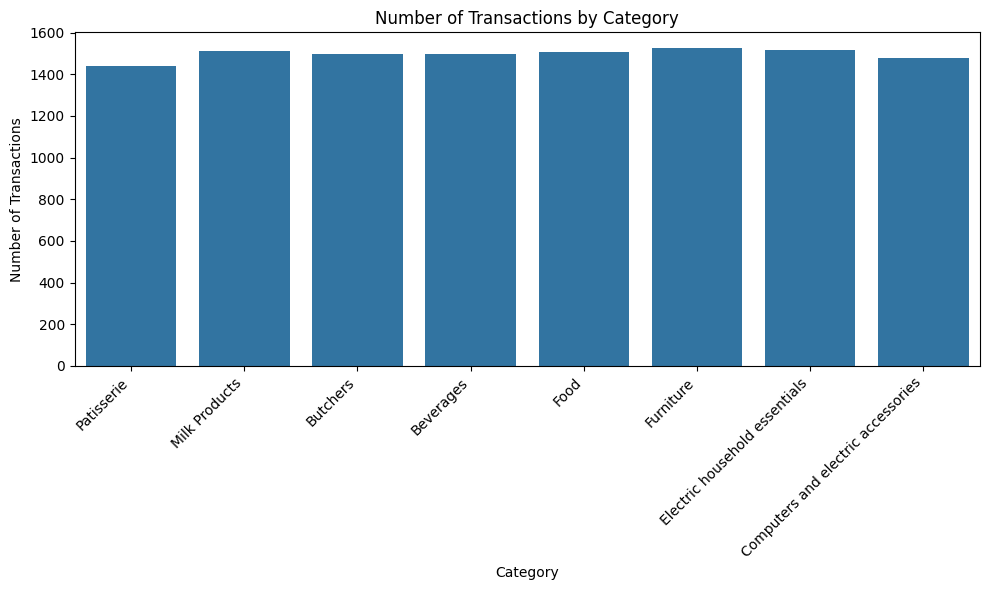

In [18]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x="Category")

plt.xticks(rotation= 45, ha="right")
plt.title("Number of Transactions by Category")
plt.xlabel("Category")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

Insight 1

Category Distribution Visualization

The number of transactions is fairly evenly distributed across categories. Furniture has the highest number of transactions, while Patisserie has the lowest. The *difference between them is relatively small*.

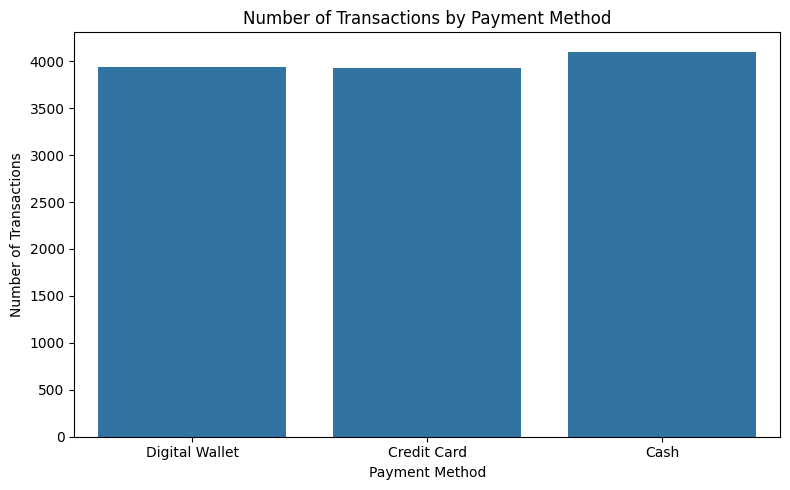

In [19]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Payment Method")

plt.title("Number of Transactions by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

Insight 2

Payment Method Visualization

Cash is the most commonly used payment method, with 4,103 transactions. Digital Wallet and Credit Card usage is very similar, with 3,941 and 3,927 transactions respectively

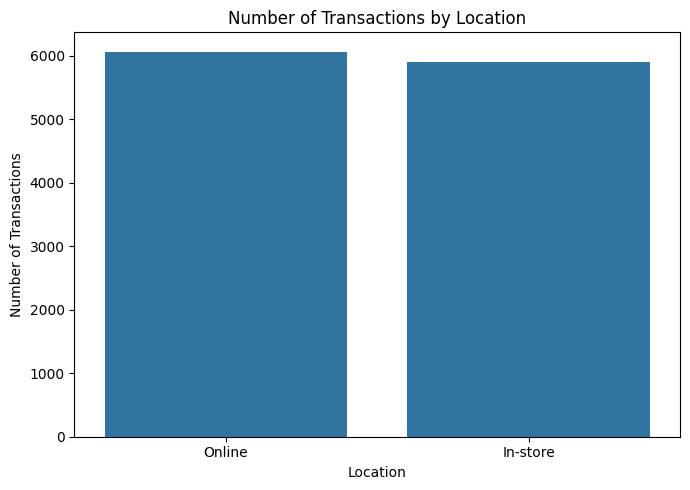

In [20]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Location")

plt.title("Number of Transactions by Location")
plt.xlabel("Location")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

Insight 3

Location Distribution Visualization

Online transactions are slightly more common than in-store transactions, with 6,068 online transactions compared to 5,903 in-store transactions. This indicates *a relatively balanced distribution between online and in-store purchases*, with a small preference toward online transactions.


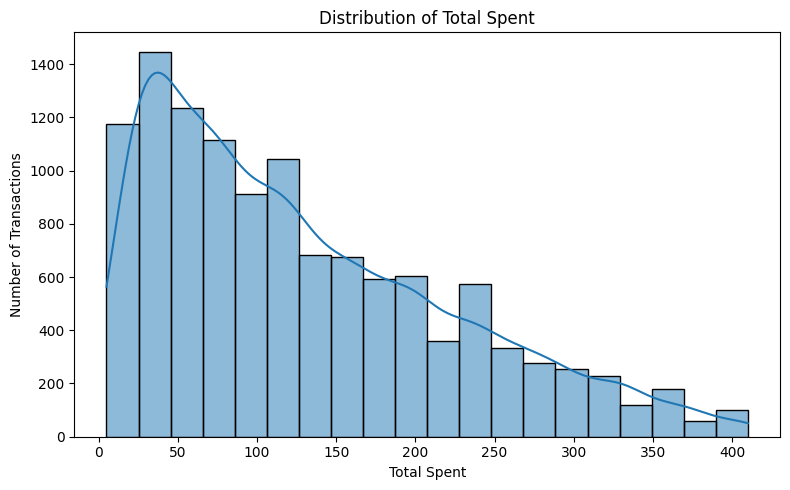

In [21]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Total Spent", bins=20, kde=True)

plt.title("Distribution of Total Spent")
plt.xlabel("Total Spent")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

Insight 4

Total Spent Distribution

The distribution of Total Spent shows that most transactions fall within the ₹0–₹50 range, with more than 1,400 transactions. *As the spending amount increases, the number of transactions generally decreases*. The ₹350–₹400 range has fewer than 200 transactions.

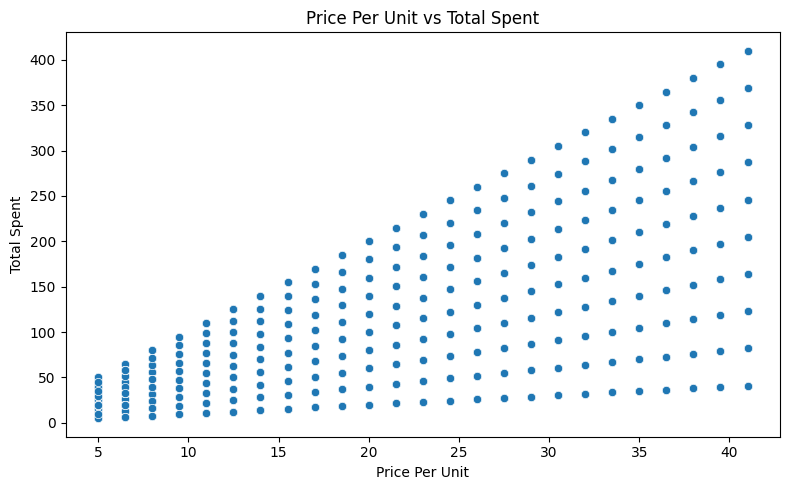

In [22]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Price Per Unit", y="Total Spent")

plt.title("Price Per Unit vs Total Spent")
plt.xlabel("Price Per Unit")
plt.ylabel("Total Spent")
plt.tight_layout()
plt.show()

Insight 5

Price Per Unit vs Total Spent

There is a positive relationship between Price Per Unit and Total Spent. As the price per unit increases, the total amount spent generally increases. This relationship is expected because Total Spent is calculated using Price Per Unit and Quantity.

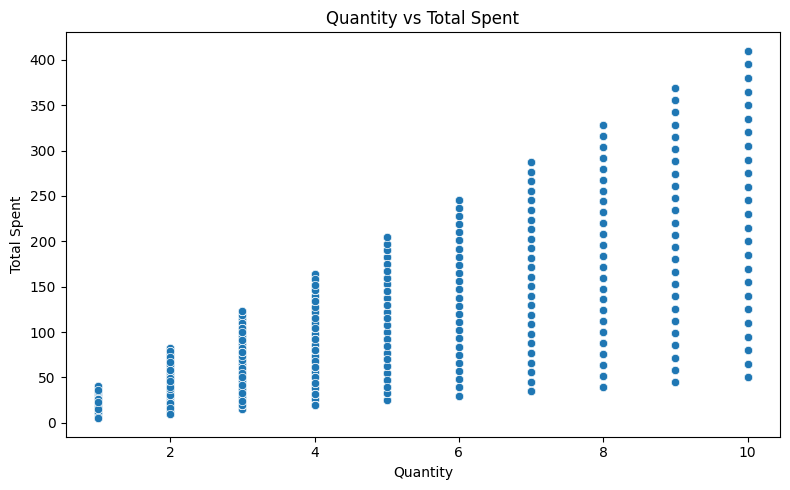

In [23]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Total Spent"
)

plt.title("Quantity vs Total Spent")
plt.xlabel("Quantity")
plt.ylabel("Total Spent")

plt.tight_layout()
plt.show()

Insight 6

Quantity vs Total Spent

Total Spent shows a clear positive relationship with Quantity. *Transactions with higher quantities generally have higher total spending*. However, spending also varies within each quantity level because products have different prices per unit.

In [24]:
correlation = df[["Price Per Unit", "Quantity", "Total Spent"]].corr()

print(correlation)

                Price Per Unit  Quantity  Total Spent
Price Per Unit        1.000000  0.010357     0.630616
Quantity              0.010357  1.000000     0.712069
Total Spent           0.630616  0.712069     1.000000


Correlation:

Correlation ranges from -1 to +1:
- +1 → strong positive relationship
- 0 → no linear relationship
- -1 → strong negative relationship

Quantity has the *strongest positive correlation* with Total Spent (0.712), followed by Price Per Unit (0.631). Price Per Unit and Quantity have *almost no correlation* (0.010), indicating that the *quantity purchased is largely independent of the unit price*.


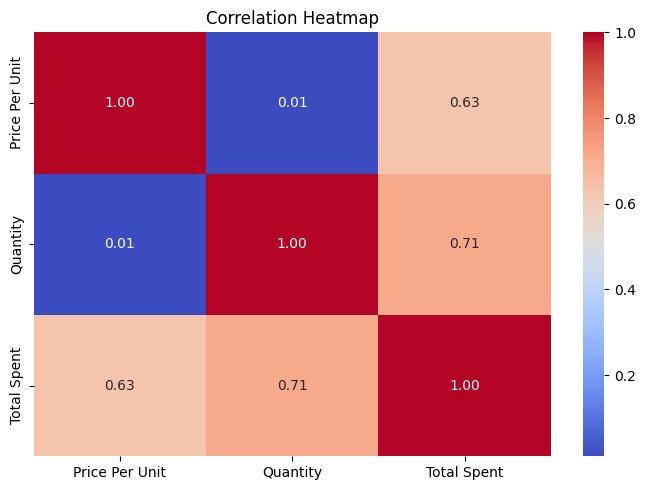

In [25]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Correlation Heatmap:

The correlation heatmap confirms that Quantity has the strongest positive relationship with Total Spent, followed by Price Per Unit. Price Per Unit and Quantity show almost no correlation.

In [27]:
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])
print(df["Transaction Date"].dtype)

datetime64[ns]


In [28]:
print(df["Transaction Date"].min())
print(df["Transaction Date"].max())

2022-01-01 00:00:00
2025-01-18 00:00:00


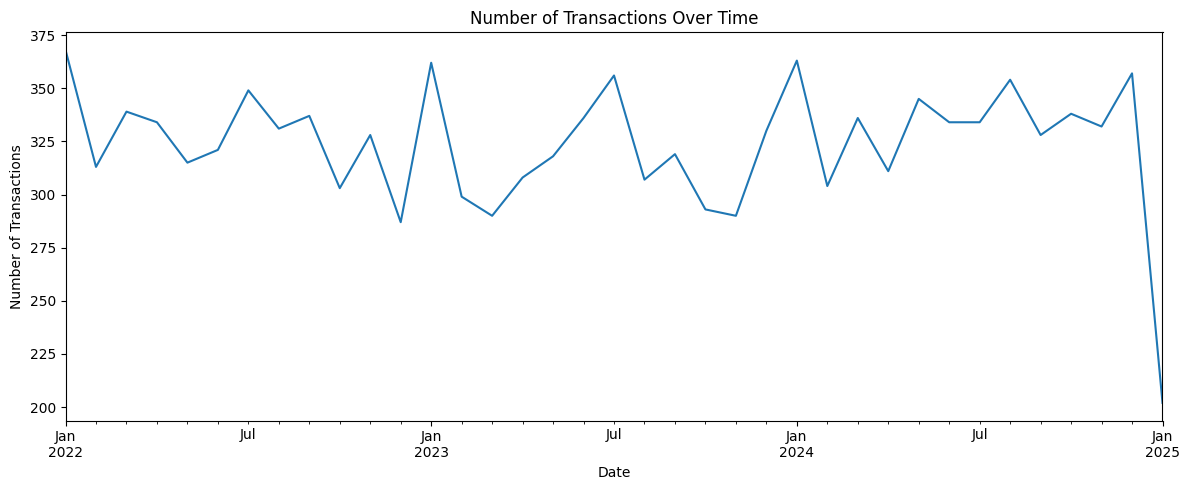

In [29]:
monthly_transactions = df.set_index("Transaction Date").resample("ME").size()

plt.figure(figsize=(12, 5))
monthly_transactions.plot()
plt.title("Number of Transactions Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

Insight 8

Time-Based Transaction

The number of monthly transactions remains *relatively stable over the period, generally fluctuating between approximately 275 and 375 transactions*. The lower count in January 2025 is due to the dataset ending on January 18, 2025, making that month incomplete.


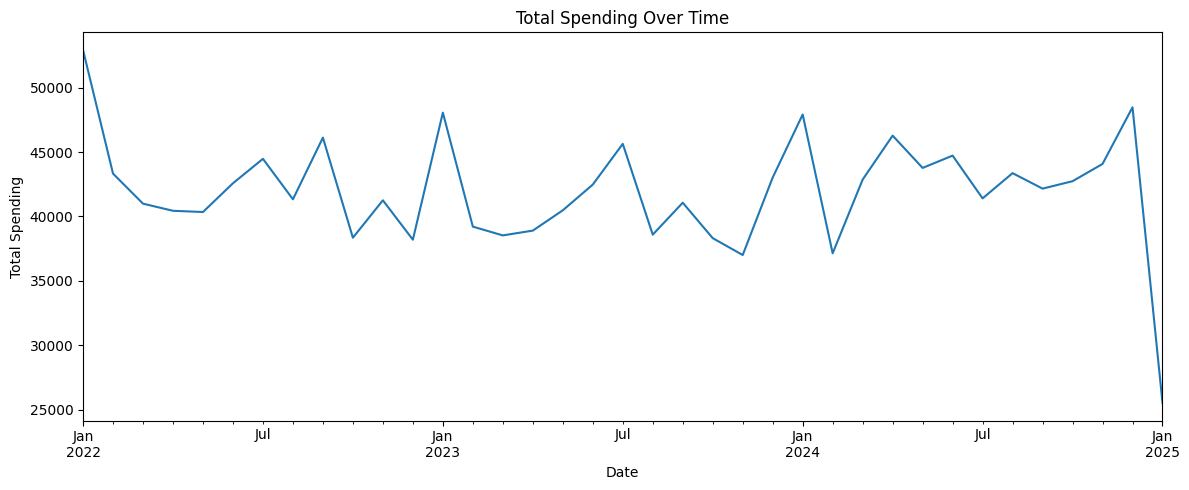

In [30]:
monthly_spending = df.set_index("Transaction Date")["Total Spent"].resample("ME").sum()

plt.figure(figsize=(12, 5))
monthly_spending.plot()
plt.title("Total Spending Over Time")
plt.xlabel("Date")
plt.ylabel("Total Spending")
plt.tight_layout()
plt.show()

Insight 9

Spending Over Time

Monthly total spending remains relatively stable throughout the dataset, *generally ranging between approximately ₹35,000 and ₹60,000*. There are normal month-to-month fluctuations, while the lower spending observed in January 2025 is mainly due to the incomplete data for that month.

In [31]:
print(df["Discount Applied"].value_counts())

Discount Applied
True       4019
Unknown    3988
False      3964
Name: count, dtype: int64


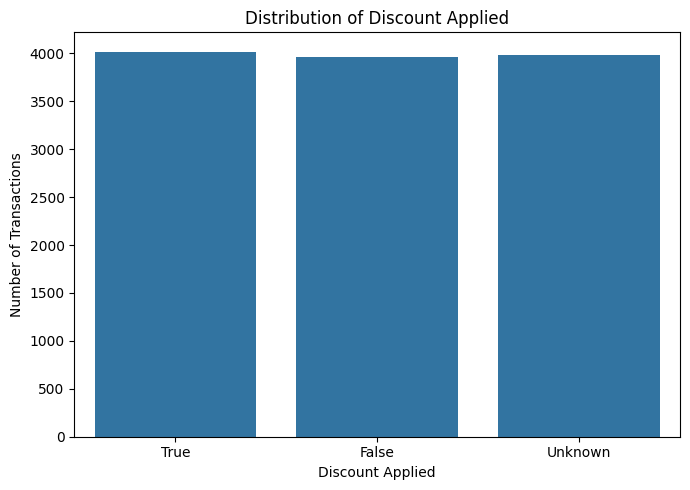

In [32]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Discount Applied")
plt.title("Distribution of Discount Applied")
plt.xlabel("Discount Applied")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

Insight 10

Discount Distribution

Discount status is almost evenly distributed across the dataset which is slightly higher than the other two, with 4,019 transactions marked as having a discount, 3,964 without a discount, and 3,988 with an unknown status.

## EDA Summary

- Transactions are fairly evenly distributed across product categories.
- Cash is the most commonly used payment method.
- Online and in-store transactions are relatively balanced.
- Most transactions have lower spending, with fewer high-value purchases.
- Quantity and Price Per Unit both show positive relationships with Total Spent.
- Quantity has the strongest correlation with Total Spent (0.712).
- Monthly transactions and spending remain relatively stable over time.
- Discount statuses are almost evenly distributed across True, False, and Unknown.
- January 2025 has lower values because the dataset ends on January 18, 2025.